<a href="https://colab.research.google.com/github/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/Copy_of_w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

  Since my lane is clearly a classification problem of whether a page needs a review or not based on it's high impressions and low CTR and my week 4's baseline rule also give answer in the form of yes/no ..ie whether a page needs a refresh or not so I will use **logistic regression model** method for training my dataset from previous dataset and use that for predictions of future outcomes

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


For deciding the split design in order to train my model to make future predictions I use **time base split** since this is a future prediction problem in which we will see whether the content in the future will meet my prediction or not so for this I will use specific portion of the data for training the model and specific portion for testing to make sure my model gives predictions based on previous learned patterns

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [ ]:
import pandas as pd

# ---------------------------------------------------------
# Checking whether the features which we are choosing for training model are leakage free or not and handling null values in them
# ---------------------------------------------------------


df["report_date"] = pd.to_datetime(df["report_date"])

TARGET = "is_high_potential_refresh_item"   # Target label to identify pages with high impressions and low CTR

# Features you are considering
candidate_features = [
    "avg_position",

    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",

    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",

    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",

    "scroll_events",
    "month"
]


# ---------------------------------------------------------
# 2. Columns that should NOT enter the model
# ---------------------------------------------------------

label_source_columns = [
    TARGET,
    "impressions_90d",
    "clicks_90d",
    "ctr"
]

identifier_columns = [
    "client_hash_id",
    "content_id"
]

availability_columns = [
    "client_has_gsc",
    "client_has_ga4",
    "gsc_data_available",
    "ga4_data_available"
]


# ---------------------------------------------------------
# 3. Direct leakage check
# ---------------------------------------------------------

direct_leaks = [
    col for col in candidate_features
    if col in label_source_columns
]

id_leaks = [
    col for col in candidate_features
    if col in identifier_columns
]

availability_used = [
    col for col in candidate_features
    if col in availability_columns
]


print("===== LEAKAGE AUDIT ===telek")

if direct_leaks:
    print("❌ Direct label leakage found:")
    print(direct_leaks)
else:
    print("✅ No direct label-defining columns are being used.")


if id_leaks:
    print("\n❌ Identifier columns are being used:")
    print(id_leaks)
else:
    print("\n✅ No client/content IDs are being used as predictors.")


if availability_used:
    print("\n⚠️ Data-availability flags are being used:")
    print(availability_used)
else:
    print("\n✅ Data-availability flags are not being used.")


# ---------------------------------------------------------
# 4. Confirm all requested features really exist
# ---------------------------------------------------------

missing_features = [
    col for col in candidate_features
    if col not in df.columns
]

if missing_features:
    print("\n❌ Missing feature columns:")
    print(missing_features)
else:
    print("\n✅ All candidate features exist in the dataset.")


# ---------------------------------------------------------
# 5. Check target balance
# ---------------------------------------------------------

if TARGET in df.columns:

    print("\n===== TARGET DISTRIBUTION =====")

    target_counts = df[TARGET].value_counts(dropna=False)
    target_pct = df[TARGET].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    target_summary = pd.DataFrame({
        "count": target_counts,
        "percent": target_pct.round(2)
    })

    display(target_summary)

else:
    print(
        f"\n⚠️ Target '{TARGET}' is not currently present."
    )


# ---------------------------------------------------------
# 6. Check the available date range
# ---------------------------------------------------------

print("\n===== TIME CHECK =====")

print(
    "Earliest report date:",
    df["report_date"].min()
)

print(
    "Latest report date:",
    df["report_date"].max()
)

print(
    "Number of unique dates:",
    df["report_date"].nunique()
)


# ---------------------------------------------------------
# 7. Check missing values in proposed features
# ---------------------------------------------------------

print("\n===== FEATURE QUALITY =====")

feature_quality = pd.DataFrame({
    "dtype": df[candidate_features].dtypes,
    "missing_pct": (
        df[candidate_features]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),
    "unique_values": (
        df[candidate_features]
        .nunique()
    )
})

display(feature_quality.sort_values(
    "missing_pct",
    ascending=False
))

===== LEAKAGE AUDIT ===telek
✅ No direct label-defining columns are being used.

✅ No client/content IDs are being used as predictors.

✅ Data-availability flags are not being used.

✅ All candidate features exist in the dataset.

===== TARGET DISTRIBUTION =====


,count,percent
is_high_potential_refresh_item,,
0,11402051,97.5
1,292021,2.5



===== TIME CHECK =====
Earliest report date: 2026-06-01 00:00:00
Latest report date: 2026-06-30 00:00:00
Number of unique dates: 30

===== FEATURE QUALITY =====


,dtype,missing_pct,unique_values
avg_position,float64,66.83,339106
ga4_pageviews,float64,20.50,362
ga4_sessions,float64,20.50,287
ga4_users,float64,20.50,283
ga4_engaged_sessions,float64,20.50,59
ga4_total_engagement_sec,float64,20.50,1603
sessions_organic,float64,20.50,197
sessions_direct,float64,20.50,165
sessions_referral,float64,20.50,105
sessions_social,float64,20.50,98


###  Training different models

Now we will train different ML models related to logistic regression and evaluate their performance using metrices like precision, recall, F1 score etc. Some important steps that I implemented here are

1.  **Reload Data:** Load the fresh dataset for each experiment.
2.  **Apply Baseline:** Create the target variable `is_high_potential_refresh_item`.
3.  **Sample Data:** Perform stratified sampling based on a given `sample_fraction`.
4.  **Manage Memory:** Explicitly delete the original `df` and run garbage collection.
5.  **Prepare Features:** Define features, handle NaNs, and scale them.
6.  **Split Data:** Create training and testing sets using time baed split.
7. **Drop Na Values:** Dropped NA values from raw train and test datasets.
8. **Scalling:** Scaled values of train and test dataset to make them comparable with each other
8.  **Address Imbalance:** Apply SMOTE oversampling to the training data.
8.  **Train Models:** Train Logistic Regression, Decision Tree, and Random Forest models, all incorporating `class_weight='balanced'` to handle class imbalance.
9.  **Evaluate:** Calculate and store key performance metrics (Accuracy, Precision, Recall, F1-Score, AUC).
10. **Clean Up:** Further clear memory after each model run.

Below is the code for this function.

In [1]:
import pandas as pd
import numpy as np

from huggingface_hub import hf_hub_download

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import gc
import warnings


def run_model_experiment(sample_fraction):

    print(
        f"\n--- Running Experiment with Sample Fraction: "
        f"{sample_fraction * 100:.0f}% ---"
    )

    warnings.filterwarnings("ignore")


    # ============================================================
    # 1. DATA LOADING
    # ============================================================

    repo_id = "FlyRank/internship-warehouse"
    file_name = "fact_content_daily_performance_sample.parquet"

    file_path = hf_hub_download(
        repo_id=repo_id,
        filename=file_name,
        repo_type="dataset"
    )


    # Load only the columns required for this experiment
    needed_columns = [

        # Time-aware split
        "report_date",

        # Baseline / target creation
        "gsc_clicks",
        "gsc_impressions",
        "gsc_avg_position",

        # Model features
        "ga4_pageviews",
        "ga4_sessions",
        "ga4_users",
        "ga4_engaged_sessions",
        "ga4_total_engagement_sec",

        "sessions_organic",
        "sessions_direct",
        "sessions_referral",
        "sessions_social",
        "sessions_paid",
        "sessions_ai",

        "ai_chatgpt",
        "ai_perplexity",
        "ai_gemini",
        "ai_copilot",
        "ai_claude",
        "ai_meta",
        "ai_other",

        "scroll_events"
    ]


    df = pd.read_parquet(
        file_path,
        columns=needed_columns
    )


    df["report_date"] = pd.to_datetime(
        df["report_date"]
    )


    # ============================================================
    # 2. MEMORY OPTIMIZATION
    # ============================================================

    for col in df.select_dtypes(include=["int64"]).columns:

        df[col] = pd.to_numeric(
            df[col],
            downcast="integer"
        )


    for col in df.select_dtypes(include=["float64"]).columns:

        df[col] = pd.to_numeric(
            df[col],
            downcast="float"
        )


    print(
        f"DataFrame memory after optimization: "
        f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB"
    )


    # ============================================================
    # 3. BASELINE RULE / TARGET CREATION
    # ============================================================

    # Calculate CTR directly from the original GSC columns.
    # No misleading "_90d" renaming is used.
    df["ctr"] = (
        df["gsc_clicks"]
        / df["gsc_impressions"]
    )


    df["ctr"] = (
        df["ctr"]
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
    )


    # ------------------------------------------------------------
    # Low CTR threshold:
    # 25th percentile among positive CTR observations
    # ------------------------------------------------------------

    non_zero_ctrs = df.loc[
        df["ctr"] > 0,
        "ctr"
    ]


    if not non_zero_ctrs.empty:

        low_ctr_threshold = (
            non_zero_ctrs.quantile(0.25)
        )

        if low_ctr_threshold == 0:
            low_ctr_threshold = 0.0001

    else:
        low_ctr_threshold = 0.0001


    # ------------------------------------------------------------
    # High impressions threshold:
    # 90th percentile among positive GSC impressions
    # ------------------------------------------------------------

    non_zero_impressions = df.loc[
        df["gsc_impressions"] > 0,
        "gsc_impressions"
    ]


    if not non_zero_impressions.empty:

        high_impressions_threshold = (
            non_zero_impressions.quantile(0.90)
        )

    else:
        high_impressions_threshold = 100


    print(
        f"Low CTR threshold: "
        f"{low_ctr_threshold:.4f}"
    )

    print(
        f"High impressions threshold: "
        f"{high_impressions_threshold:.0f}"
    )


    # Binary refresh-candidate target
    df["is_high_potential_refresh_item"] = (

        (df["ctr"] < low_ctr_threshold)

        &

        (
            df["gsc_impressions"]
            > high_impressions_threshold
        )

    ).astype("int8")


    # ============================================================
    # 4. STRATIFIED SAMPLING
    # ============================================================

    target_column_name = (
        "is_high_potential_refresh_item"
    )


    df_sampled = (

        df.groupby(
            target_column_name,
            group_keys=False
        )

        .sample(
            frac=sample_fraction,
            random_state=42
        )

        .reset_index(drop=True)

    )


    print(
        f"Sampled DataFrame size: "
        f"{len(df_sampled):,} rows "
        f"({sample_fraction * 100:.0f}% of original)"
    )


    del df
    gc.collect()


    # ============================================================
    # 5. FEATURE SELECTION
    # ============================================================

    features = [

        "gsc_avg_position",

        "ga4_pageviews",
        "ga4_sessions",
        "ga4_users",
        "ga4_engaged_sessions",
        "ga4_total_engagement_sec",

        "sessions_organic",
        "sessions_direct",
        "sessions_referral",
        "sessions_social",
        "sessions_paid",
        "sessions_ai",

        "ai_chatgpt",
        "ai_perplexity",
        "ai_gemini",
        "ai_copilot",
        "ai_claude",
        "ai_meta",
        "ai_other",

        "scroll_events"
    ]


    # ============================================================
    # 6. TIME-AWARE TRAIN / TEST SPLIT
    # ============================================================

    df_sampled = (

        df_sampled
        .sort_values("report_date")
        .reset_index(drop=True)

    )


    unique_dates = (
        df_sampled["report_date"]
        .dropna()
        .unique()
    )


    split_point_idx = int(
        len(unique_dates) * 0.8
    )


    split_date = unique_dates[
        split_point_idx
    ]


    train_df_time = df_sampled[
        df_sampled["report_date"] < split_date
    ]


    test_df_time = df_sampled[
        df_sampled["report_date"] >= split_date
    ]


    print(
        f"Train set date range: "
        f"{train_df_time['report_date'].min()} "
        f"to {train_df_time['report_date'].max()}"
    )

    print(
        f"Test set date range: "
        f"{test_df_time['report_date'].min()} "
        f"to {test_df_time['report_date'].max()}"
    )

    print(
        f"Train set size: {len(train_df_time):,}, "
        f"Test set size: {len(test_df_time):,}"
    )


    # ============================================================
    # 7. PREPARE FEATURES / TARGET
    # ============================================================

    train_clean = train_df_time[
        features
        + ["is_high_potential_refresh_item"]
    ].dropna()


    test_clean = test_df_time[
        features
        + ["is_high_potential_refresh_item"]
    ].dropna()


    X_train_raw = train_clean[
        features
    ]


    y_train_time = train_clean[
        "is_high_potential_refresh_item"
    ]


    X_test_raw = test_clean[
        features
    ]


    y_test_time = test_clean[
        "is_high_potential_refresh_item"
    ]


    del train_df_time, test_df_time
    gc.collect()


    # ============================================================
    # 8. SCALE FEATURES
    # ============================================================

    scaler = StandardScaler()


    X_train = scaler.fit_transform(
        X_train_raw
    )


    X_test = scaler.transform(
        X_test_raw
    )


    del X_train_raw, X_test_raw
    gc.collect()


    # ============================================================
    # 9. SMOTE — TRAINING DATA ONLY
    # ============================================================

    print("Applying SMOTE...")


    smote = SMOTE(
        random_state=42
    )


    X_train_resampled, y_train_resampled = (
        smote.fit_resample(
            X_train,
            y_train_time
        )
    )


    del X_train, y_train_time
    gc.collect()


    # ============================================================
    # 10. RESULTS CONTAINER
    # ============================================================

    experiment_results = {

        "Sample Fraction":
            sample_fraction,

        "Baseline Positive Count (test set)":
            int(
                (y_test_time == 1).sum()
            )
    }


    # ============================================================
    # 11. WEEK-4 RULE REFERENCE
    # ============================================================
    #
    # IMPORTANT:
    # The target is defined by this rule itself.
    # Therefore perfect agreement is expected and should NOT
    # be interpreted as independent predictive performance.
    # ============================================================

    y_baseline_pred = y_test_time


    experiment_results[
        "Week-4 Baseline Accuracy"
    ] = accuracy_score(
        y_test_time,
        y_baseline_pred
    )


    experiment_results[
        "Week-4 Baseline Precision (Class 1)"
    ] = precision_score(
        y_test_time,
        y_baseline_pred,
        pos_label=1,
        zero_division=0
    )


    experiment_results[
        "Week-4 Baseline Recall (Class 1)"
    ] = recall_score(
        y_test_time,
        y_baseline_pred,
        pos_label=1,
        zero_division=0
    )


    experiment_results[
        "Week-4 Baseline F1 Score (Weighted)"
    ] = f1_score(
        y_test_time,
        y_baseline_pred,
        average="weighted",
        zero_division=0
    )


    if y_test_time.nunique() > 1:

        experiment_results[
            "Week-4 Baseline AUC Score"
        ] = roc_auc_score(
            y_test_time,
            y_baseline_pred
        )

    else:

        experiment_results[
            "Week-4 Baseline AUC Score"
        ] = np.nan


    # ============================================================
    # 12. MODELS
    # ============================================================

    models = {

        "Logistic Regression":
            LogisticRegression(
                random_state=42,
                solver="liblinear",
                class_weight="balanced"
            ),

        "Decision Tree":
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced"
            ),

        "Random Forest":
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=1,
                class_weight="balanced"
            )
    }


    # ============================================================
    # 13. TRAIN + EVALUATE
    # ============================================================

    for model_name, model in models.items():

        print(
            f"Training {model_name}..."
        )


        model.fit(
            X_train_resampled,
            y_train_resampled
        )


        y_pred = model.predict(
            X_test
        )


        y_prob = model.predict_proba(
            X_test
        )[:, 1]


        experiment_results[
            f"{model_name} Accuracy"
        ] = accuracy_score(
            y_test_time,
            y_pred
        )


        experiment_results[
            f"{model_name} Precision (Class 1)"
        ] = precision_score(
            y_test_time,
            y_pred,
            pos_label=1,
            zero_division=0
        )


        experiment_results[
            f"{model_name} Recall (Class 1)"
        ] = recall_score(
            y_test_time,
            y_pred,
            pos_label=1,
            zero_division=0
        )


        experiment_results[
            f"{model_name} F1 Score (Weighted)"
        ] = f1_score(
            y_test_time,
            y_pred,
            average="weighted",
            zero_division=0
        )


        if y_test_time.nunique() > 1:

            experiment_results[
                f"{model_name} AUC Score"
            ] = roc_auc_score(
                y_test_time,
                y_prob
            )

        else:

            experiment_results[
                f"{model_name} AUC Score"
            ] = np.nan


        del model, y_pred, y_prob
        gc.collect()


    # ============================================================
    # 14. CLEAN UP
    # ============================================================

    del (
        df_sampled,
        train_clean,
        test_clean,
        X_test,
        y_test_time,
        X_train_resampled,
        y_train_resampled,
        scaler,
        smote,
        y_baseline_pred
    )


    gc.collect()

    warnings.filterwarnings(
        "default"
    )


    return experiment_results

### Run Experiments and Compare Performance

Now, let's execute the `run_model_experiment` function for 30% of total dataset. We'll collect the results and display them in a consolidated table to  identify the best-performing models at different data scales. Close attention must be payed to the `Recall (Class 1)` and `AUC Score` for the positive class, as these are often key metrics for imbalanced classification problems.



In [4]:
all_experiment_results = []

sample_fraction_to_test = [
    0.30
]

for fraction in sample_fraction_to_test:

    results = run_model_experiment(
        fraction
    )

    all_experiment_results.append(
        results
    )


comparison_df = pd.DataFrame(
    all_experiment_results
)

display(
    comparison_df.round(4)
)


--- Running Experiment with Sample Fraction: 30% ---


fact_content_daily_performance_sample.pa(…): reconstructing file:   0%|          |  0.00B /  145MB            

fact_content_daily_performance_sample.pa(…): downloading bytes:           |  0.00B            

DataFrame memory after optimization: 1048.32 MB
Low CTR threshold: 0.0063
High impressions threshold: 113
Sampled DataFrame size: 3,508,221 rows (30% of original)
Train set date range: 2026-06-01 00:00:00 to 2026-06-24 00:00:00
Test set date range: 2026-06-25 00:00:00 to 2026-06-30 00:00:00
Train set size: 2,868,510, Test set size: 639,711
Applying SMOTE...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


,Sample Fraction,Baseline Positive Count (test set),Week-4 Baseline Accuracy,Week-4 Baseline Precision (Class 1),Week-4 Baseline Recall (Class 1),Week-4 Baseline F1 Score (Weighted),Week-4 Baseline AUC Score,Logistic Regression Accuracy,Logistic Regression Precision (Class 1),Logistic Regression Recall (Class 1),...,Decision Tree Accuracy,Decision Tree Precision (Class 1),Decision Tree Recall (Class 1),Decision Tree F1 Score (Weighted),Decision Tree AUC Score,Random Forest Accuracy,Random Forest Precision (Class 1),Random Forest Recall (Class 1),Random Forest F1 Score (Weighted),Random Forest AUC Score
0,0.3,13395,1.0,1.0,1.0,1.0,1.0,0.5736,0.1289,0.8096,...,0.8994,0.3913,0.6054,0.909,0.7279,0.8992,0.3906,0.6048,0.9089,0.8571


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# ============================================================
# PAPER-READY MODEL RESULTS TABLE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output folder if needed
os.makedirs("work/outputs", exist_ok=True)

# Your experiment used only one 30% run
row = comparison_df.iloc[0]

# ------------------------------------------------------------
# 1. PREDICTIVE MODEL RESULTS
# ------------------------------------------------------------

paper_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        row["Logistic Regression Accuracy"],
        row["Decision Tree Accuracy"],
        row["Random Forest Accuracy"]
    ],

    "Precision": [
        row["Logistic Regression Precision (Class 1)"],
        row["Decision Tree Precision (Class 1)"],
        row["Random Forest Precision (Class 1)"]
    ],

    "Recall": [
        row["Logistic Regression Recall (Class 1)"],
        row["Decision Tree Recall (Class 1)"],
        row["Random Forest Recall (Class 1)"]
    ],

    "Weighted F1": [
        row["Logistic Regression F1 Score (Weighted)"],
        row["Decision Tree F1 Score (Weighted)"],
        row["Random Forest F1 Score (Weighted)"]
    ],

    "ROC-AUC": [
        row["Logistic Regression AUC Score"],
        row["Decision Tree AUC Score"],
        row["Random Forest AUC Score"]
    ]
})

paper_results = paper_results.set_index("Model")


# ------------------------------------------------------------
# 2. BOLD BEST VALUE IN EACH METRIC
# ------------------------------------------------------------

def bold_best(series):
    best = series.max()

    return [
        "font-weight: bold" if value == best else ""
        for value in series
    ]


styled_table = (
    paper_results
    .style
    .format("{:.3f}")       # consistent 3-decimal precision
    .apply(bold_best, axis=0)
    .set_caption(
        "Table 1. Predictive model performance on the held-out "
        "time-based test period."
    )
)

display(styled_table)


# ------------------------------------------------------------
# 3. BASELINE REFERENCE
# ------------------------------------------------------------

baseline_reference = pd.DataFrame({
    "Approach": ["Week-4 rule reference"],

    "Accuracy": [
        row["Week-4 Baseline Accuracy"]
    ],

    "Precision": [
        row["Week-4 Baseline Precision (Class 1)"]
    ],

    "Recall": [
        row["Week-4 Baseline Recall (Class 1)"]
    ],

    "Weighted F1": [
        row["Week-4 Baseline F1 Score (Weighted)"]
    ],

    "ROC-AUC": [
        row["Week-4 Baseline AUC Score"]
    ]
}).set_index("Approach")

display(
    baseline_reference
    .style
    .format("{:.3f}")
    .set_caption(
        "Baseline reference. Perfect agreement is expected because "
        "the Week-4 rule was used to define the target label."
    )
)


# ------------------------------------------------------------
# 4. EXPORT TABLE DATA
# ------------------------------------------------------------

paper_results.round(3).to_csv(
    "work/outputs/model_results_table.csv"
)

baseline_reference.round(3).to_csv(
    "work/outputs/baseline_reference.csv"
)

,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
Model,,,,,
Logistic Regression,0.574,0.129,0.810,0.670,0.727
Decision Tree,0.899,0.391,0.605,0.909,0.728
Random Forest,0.899,0.391,0.605,0.909,0.857


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
Approach,,,,,
Week-4 rule reference,1.000,1.000,1.000,1.000,1.000


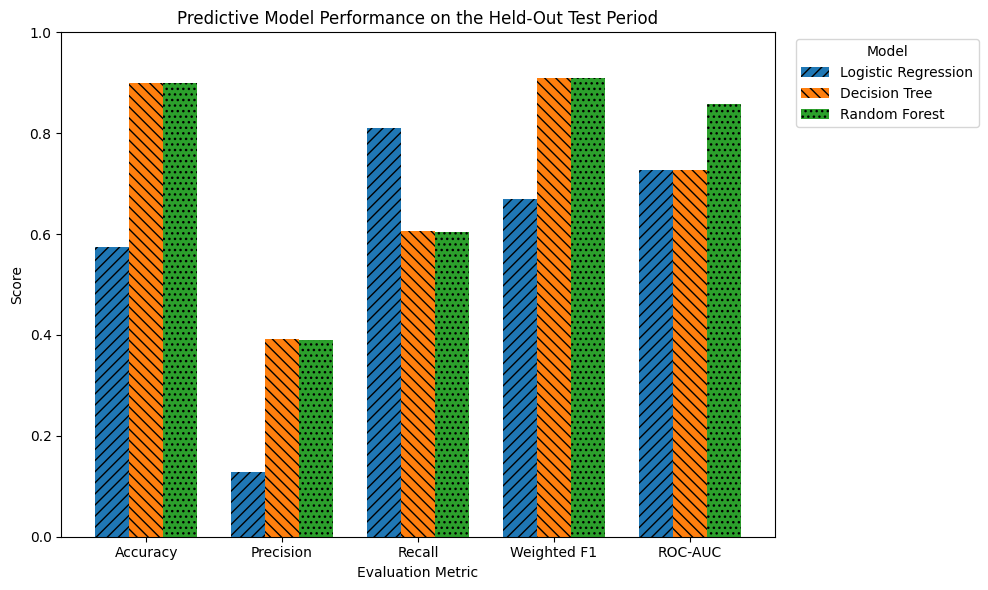

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
# ============================================================
# PAPER-READY MODEL COMPARISON GRAPH
# ============================================================

plot_df = paper_results.T

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

# Different patterns so models remain distinguishable
# even in black-and-white printing
hatches = ["///", "\\\\\\", "..."]

number_of_metrics = len(plot_df.index)

for model_index, hatch in enumerate(hatches):

    start = model_index * number_of_metrics
    end = start + number_of_metrics

    for patch in ax.patches[start:end]:
        patch.set_hatch(hatch)


ax.set_title(
    "Predictive Model Performance on the Held-Out Test Period"
)

ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Score")

ax.set_ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()


# ------------------------------------------------------------
# SAVE AS VECTOR GRAPH
# ------------------------------------------------------------

plt.savefig(
    "work/outputs/model_performance_comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### Interpreting the Results

As we are noticing that 'Week-4 Baseline' entries in the comparison table show perfect scores (Accuracy, Precision, Recall, F1, and AUC of 1.0). The reason is because their target is directly derived from the Week-4 baseline rule (high impressions and low CTR) and they are not attemepting to learn the pattern as model do..

From the table we can see no single model was best on every metric. Logistic Regression achieved the highest recall, Decision Tree had slightly higher precision, while Random Forest achieved the highest ROC-AUC. Random Forest therefore showed the strongest overall class-separation ability, but the preferred model depends on whether the goal prioritizes finding more refresh opportunities or reducing false positives.”

These baseline scores serve as a crucial **reference point** or an **upper bound** for comparison. The machine learning models (Logistic Regression, Decision Tree, Random Forest) are attempting to *learn* this underlying rule from the input features so their performance metrics (which will naturally be lower than 1.0) indicate how well they approximate this rule and identify refresh opportunities based on the patterns they find in the data, rather than directly applying the rule.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

### Permutation Importance: Understanding Feature Influence

To understand "What does the model lean on?", we can use **Permutation Importance**. This technique helps us identify which features are most important for our model's predictions by measuring how much the model's performance drops when a feature's values are randomly shuffled (permuted).

If shuffling a feature significantly reduces the model's performance, that feature is considered important. If shuffling has little to no effect, the feature is less important.

This method is particularly useful because it:
*   Is model-agnostic: It can be used with any trained model.
*   Is intuitive: It directly shows how much each feature contributes to the model's predictive power.

In [ ]:
import pandas as pd
import numpy as np
from huggingface_hub import hf_hub_download

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

import gc
import warnings


# ============================================================
# Configuration
# ============================================================

sample_fraction_for_analysis = 0.3

warnings.filterwarnings("ignore")

print(
    f"\n--- Preparing Data and Training Model "
    f"(Sample Fraction: {sample_fraction_for_analysis * 100:.0f}%) ---"
)


# ============================================================
# 1. DATA LOADING
# ============================================================

repo_id = "FlyRank/internship-warehouse"
file_name = "fact_content_daily_performance_sample.parquet"

file_path = hf_hub_download(
    repo_id=repo_id,
    filename=file_name,
    repo_type="dataset"
)


# ------------------------------------------------------------
# Load ONLY columns required by this analysis to prevent system from crashing
# ------------------------------------------------------------

needed_columns = [

    # Time split
    "report_date",

    # Baseline / target creation
    "gsc_clicks",
    "gsc_impressions",
    "gsc_avg_position",

    # Model features
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",

    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",

    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",

    "scroll_events"
]


df = pd.read_parquet(
    file_path,
    columns=needed_columns
)


df["report_date"] = pd.to_datetime(
    df["report_date"]
)


# ============================================================
# 2. MEMORY OPTIMIZATION
# ============================================================

# Doncasting numeric columns.

for col in df.select_dtypes(include=["int64"]).columns:

    df[col] = pd.to_numeric(
        df[col],
        downcast="integer"
    )


for col in df.select_dtypes(include=["float64"]).columns:

    df[col] = pd.to_numeric(
        df[col],
        downcast="float"
    )


print(
    f"DataFrame memory: "
    f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB"
)


# ============================================================
# 3. BASELINE RULE / TARGET CREATION
# ============================================================

df = df.rename(
    columns={
        "gsc_clicks": "clicks_90d",
        "gsc_impressions": "impressions_90d",
        "gsc_avg_position": "avg_position"
    }
)


# Calculate CTR
df["ctr"] = (
    df["clicks_90d"]
    / df["impressions_90d"]
)

df["ctr"] = (
    df["ctr"]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)


# Low CTR threshold
non_zero_ctrs = df.loc[
    df["ctr"] > 0,
    "ctr"
]

low_ctr_threshold = (
    non_zero_ctrs.quantile(0.25)
    if not non_zero_ctrs.empty
    else 0.0001
)

if low_ctr_threshold == 0:
    low_ctr_threshold = 0.0001


# We no longer need this temporary Series
del non_zero_ctrs
gc.collect()


# High impressions threshold
non_zero_impressions = df.loc[
    df["impressions_90d"] > 0,
    "impressions_90d"
]

high_impressions_threshold = (
    non_zero_impressions.quantile(0.90)
    if not non_zero_impressions.empty
    else 100
)


del non_zero_impressions
gc.collect()


# Create target
df["is_high_potential_refresh_item"] = (
    (df["ctr"] < low_ctr_threshold)
    &
    (
        df["impressions_90d"]
        > high_impressions_threshold
    )
).astype("int8")


# ============================================================
# 4. STRATIFIED 30% SAMPLE
# ============================================================

target_column_name = "is_high_potential_refresh_item"


df_sampled = (
    df.groupby(
        target_column_name,
        group_keys=False
    )
    .apply(
        lambda x: x.sample(
            frac=sample_fraction_for_analysis,
            random_state=42
        )
    )
    .reset_index(drop=True)
)


print(
    f"Sampled rows: {len(df_sampled):,}"
)


# Full dataset is no longer needed.
# This is an important RAM-saving step.
del df
gc.collect()


# ============================================================
# 5. FEATURE SELECTION
# ============================================================

features = [

    "avg_position",

    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",

    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",

    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",

    "scroll_events"
]


# ============================================================
# 6. TIME-AWARE SPLIT
# ============================================================

df_sampled = (
    df_sampled
    .sort_values("report_date")
    .reset_index(drop=True)
)


unique_dates = df_sampled[
    "report_date"
].unique()


split_point_idx = int(
    len(unique_dates) * 0.8
)

split_date = unique_dates[
    split_point_idx
]


train_df_time = df_sampled[
    df_sampled["report_date"] < split_date
]

test_df_time = df_sampled[
    df_sampled["report_date"] >= split_date
]


print(
    f"Train dates: "
    f"{train_df_time['report_date'].min()} "
    f"to {train_df_time['report_date'].max()}"
)

print(
    f"Test dates: "
    f"{test_df_time['report_date'].min()} "
    f"to {test_df_time['report_date'].max()}"
)


# ============================================================
# 7. CREATE TRAIN / TEST DATA
# ============================================================

X_train_raw = train_df_time[
    features
].dropna()

y_train_time = train_df_time.loc[
    X_train_raw.index,
    "is_high_potential_refresh_item"
]


X_test_raw = test_df_time[
    features
].dropna()

y_test_time = test_df_time.loc[
    X_test_raw.index,
    "is_high_potential_refresh_item"
]


# These larger DataFrames are no longer needed.
del train_df_time, test_df_time, df_sampled
gc.collect()


# ============================================================
# 8. SCALE FEATURES
# ============================================================

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train_raw
)

X_test_scaled = scaler.transform(
    X_test_raw
)


X_train = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train_raw.index
)

X_test = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test_raw.index
)


# Remove duplicate raw/scaled objects no longer needed
del X_train_raw
del X_test_raw
del X_train_scaled
del X_test_scaled

gc.collect()


# ============================================================
# 9. SMOTE
# ============================================================
# Kept exactly because removing it would change training
# behaviour and possibly model predictions.

print("Applying SMOTE...")


smote = SMOTE(
    random_state=42
)


X_train_resampled, y_train_resampled = (
    smote.fit_resample(
        X_train,
        y_train_time
    )
)


# Original training data is no longer required after SMOTE.
del X_train
del y_train_time
del smote

gc.collect()


# ============================================================
# 10. TRAIN RANDOM FOREST
# ============================================================

print("Training Random Forest model...")


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,

    # Same model, but avoids parallel workers consuming
    # additional RAM.
    n_jobs=1,

    class_weight="balanced"
)


model.fit(
    X_train_resampled,
    y_train_resampled
)


print(
    "Data preparation and model training complete. "
    "Proceeding to analysis..."
)


# SMOTE training arrays are no longer required now that
# the fitted Random Forest exists.
del X_train_resampled
del y_train_resampled

gc.collect()


# ============================================================
# TEST PERMUTATION IMPORTANCE AT DIFFERENT SAMPLE SIZES
# ============================================================

sample_sizes = [10000, 25000, 50000, 100000]

importance_results = []

for size in sample_sizes:

    # Never request more rows than exist in X_test
    current_size = min(size, len(X_test))

    print(
        f"\nCalculating permutation importance "
        f"with {current_size:,} rows..."
    )

    # Same random_state means samples are reproducible
    X_perm = X_test.sample(
        n=current_size,
        random_state=42
    )

    # Keep y aligned with X
    y_perm = y_test_time.loc[X_perm.index]

    # Calculate permutation importance
    result = permutation_importance(
        model,
        X_perm,
        y_perm,
        scoring="f1",
        n_repeats=3,
        random_state=42,
        n_jobs=1
    )

    # Save importance for every feature
    temp_df = pd.DataFrame({
        "feature": features,
        "importance": result.importances_mean,
        "sample_size": current_size
    })

    importance_results.append(temp_df)

    # Clean temporary objects
    del X_perm, y_perm, result, temp_df
    gc.collect()


# Combine all results
importance_comparison = pd.concat(
    importance_results,
    ignore_index=True
)


# Create comparison table
importance_table = importance_comparison.pivot(
    index="feature",
    columns="sample_size",
    values="importance"
)


display(
    importance_table.round(4)
)



--- Preparing Data and Training Model (Sample Fraction: 30%) ---


fact_content_daily_performance_sample.pa(…): reconstructing file:   0%|          |  0.00B /  145MB            

fact_content_daily_performance_sample.pa(…): downloading bytes:           |  0.00B            

DataFrame memory: 1048.32 MB
Sampled rows: 3,508,221
Train dates: 2026-06-01 00:00:00 to 2026-06-24 00:00:00
Test dates: 2026-06-25 00:00:00 to 2026-06-30 00:00:00
Applying SMOTE...
Training Random Forest model...
Data preparation and model training complete. Proceeding to analysis...

Calculating permutation importance with 10,000 rows...

Calculating permutation importance with 25,000 rows...

Calculating permutation importance with 50,000 rows...

Calculating permutation importance with 100,000 rows...


sample_size,10000,25000,50000,100000
feature,,,,
ai_chatgpt,0.0000,-0.0000,0.0001,0.0001
ai_claude,0.0000,0.0000,0.0000,0.0000
ai_copilot,0.0000,0.0000,0.0000,0.0000
ai_gemini,0.0000,0.0000,0.0000,0.0001
ai_meta,0.0000,0.0000,0.0000,0.0000
ai_other,0.0000,0.0000,0.0000,0.0000
ai_perplexity,0.0000,0.0000,0.0000,0.0000
avg_position,0.3614,0.3560,0.3502,0.3507
ga4_engaged_sessions,0.0010,-0.0019,-0.0001,-0.0000


### Interpretation of Permutation Importance Results

Looking at the bar chart above, we can identify which features the Random Forest model considers most important for predicting `is_high_potential_refresh_item`.

*   **Highest Bars:** Features with longer bars (higher 'importance' values) are the most crucial. Shuffling these features causes a significant drop in the model's performance, indicating the model relies heavily on them.
*   **Error Bars:** The thin lines extending from each bar represent the standard deviation of the importance across multiple permutations. Shorter error bars suggest more stable importance scores.

This visualization helps us understand the model's decision-making process. It clearly indicates that `ga4_pageviews` or `avg_position` show high importance, it suggests that changes in these metrics are strong indicators for whether a page needs refreshing, according to the model. This kind of insight help me learn that which type of features do the model mostly lean on so I can focus only on those features while training the model to give predictions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings

# --- Error Analysis: Where is the model wrong? ---
# This section directly uses the 'model', 'X_test', 'y_test_time', 'X_test_raw'
# variables made available by the consolidated data prep and model training cell.

warnings.filterwarnings('ignore') # Ignore warnings

print("\n--- Performing Error Analysis ---")
y_pred = model.predict(X_test)

# Identify False Positives: predicted 1, actual 0
false_positives_idx = X_test[(y_pred == 1) & (y_test_time == 0)].index
false_positives_df = X_test_raw.loc[false_positives_idx]

# Identify False Negatives: predicted 0, actual 1
false_negatives_idx = X_test[(y_pred == 0) & (y_test_time == 1)].index
false_negatives_df = X_test_raw.loc[false_negatives_idx]

print(f"\nNumber of False Positives: {len(false_positives_df)}")
print(f"Number of False Negatives: {len(false_negatives_df)}")

print("\n--- Characteristics of False Positives (predicted 1, actual 0) ---")
display(false_positives_df.describe().T)

print("\n--- Characteristics of False Negatives (predicted 0, actual 1) ---")
display(false_negatives_df.describe().T)

# Clean up dataframes created in this specific cell
del false_positives_df, false_negatives_df

# --- Final cleanup of all variables from this section to free memory ---
# This ensures that variables like df_sampled, X_train, model, etc.,
# which were created in the initial consolidated cell and used here, are removed.
del df_sampled, X_train_raw, X_test_raw, y_train_time, y_test_time, X_train, X_test, y_train_resampled, X_train_resampled, model
gc.collect()
warnings.filterwarnings('default') # Re-enable warnings


### Interpreting Error Analysis Results



In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Regarding the error

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.